In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 세 CSV 불러오기
viirs = pd.read_csv("../data/processed/viirs_nightlight_2025.csv")
roads = pd.read_csv("../data/processed/road_density_2026.csv")
water = pd.read_csv("../data/processed/water_density_2026.csv")

# 합치기
df = viirs.merge(roads[['district_name', 'road_density_km_per_sqkm']], on='district_name')
df = df.merge(water[['district_name', 'water_density_km_per_sqkm']], on='district_name')

print(df.columns.tolist())
print(df)

['district_name', 'city', 'mean_radiance', 'road_density_km_per_sqkm', 'water_density_km_per_sqkm']
   district_name     city  mean_radiance  road_density_km_per_sqkm  \
0     Douala 1er   Douala      13.997540                  8.266550   
1      Douala 2e   Douala      10.254959                 12.203973   
2      Douala 3e   Douala       6.136908                  9.896716   
3      Douala 4e   Douala       2.287667                  2.493050   
4      Douala 5e   Douala       4.262470                  6.991505   
5      Douala 6e   Douala       0.367691                  0.107476   
6    Yaounde 1er  Yaounde      14.165398                 14.338806   
7     Yaounde 2e  Yaounde      10.901530                  8.227689   
8     Yaounde 3e  Yaounde       7.979103                  7.014594   
9     Yaounde 4e  Yaounde      13.229417                 14.126752   
10    Yaounde 5e  Yaounde      18.220761                 17.991859   
11    Yaounde 6e  Yaounde      13.250827                 14.

In [3]:
# 분석에 쓸 지표 3개
features = ['mean_radiance', 'road_density_km_per_sqkm', 'water_density_km_per_sqkm']

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])
df_scaled = pd.DataFrame(df_scaled, columns=features, index=df['district_name'])

print("정규화 완료!")
print(df_scaled.round(3))

정규화 완료!
               mean_radiance  road_density_km_per_sqkm  \
district_name                                            
Douala 1er             0.917                    -0.321   
Douala 2e              0.178                     0.493   
Douala 3e             -0.635                     0.016   
Douala 4e             -1.395                    -1.515   
Douala 5e             -1.005                    -0.585   
Douala 6e             -1.774                    -2.008   
Yaounde 1er            0.950                     0.934   
Yaounde 2e             0.306                    -0.329   
Yaounde 3e            -0.271                    -0.580   
Yaounde 4e             0.765                     0.890   
Yaounde 5e             1.751                     1.689   
Yaounde 6e             0.770                     0.941   
Yaounde 7e            -0.557                     0.374   

               water_density_km_per_sqkm  
district_name                             
Douala 1er                        -

In [4]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(df_scaled)

# 각 주성분이 설명하는 분산 비율
print("각 PC 설명 분산 비율:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.3f} ({ratio*100:.1f}%)")

print(f"\nPC1+PC2 누적: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")

# 각 지표가 PC1에 기여하는 방향 (loadings)
print("\nPC1 loadings (각 지표의 기여도):")
for feat, loading in zip(features, pca.components_[0]):
    print(f"  {feat}: {loading:.3f}")

각 PC 설명 분산 비율:
  PC1: 0.804 (80.4%)
  PC2: 0.158 (15.8%)
  PC3: 0.037 (3.7%)

PC1+PC2 누적: 96.3%

PC1 loadings (각 지표의 기여도):
  mean_radiance: 0.579
  road_density_km_per_sqkm: 0.618
  water_density_km_per_sqkm: 0.532


In [5]:
# PC1 점수를 종합 인프라 지수로
df['infra_index'] = pca_result[:, 0]
df['PC2'] = pca_result[:, 1]

# 순위 확인
print(df[['district_name', 'city', 'infra_index']].sort_values('infra_index', ascending=False).to_string(index=False))

district_name    city  infra_index
   Yaounde 5e Yaounde     2.540264
   Yaounde 6e Yaounde     1.621467
   Yaounde 4e Yaounde     1.302393
  Yaounde 1er Yaounde     1.270814
    Douala 2e  Douala     1.252603
   Yaounde 7e Yaounde     0.463984
   Douala 1er  Douala     0.132775
   Yaounde 2e Yaounde    -0.231480
    Douala 3e  Douala    -0.590097
   Yaounde 3e Yaounde    -1.226778
    Douala 4e  Douala    -1.713023
    Douala 5e  Douala    -1.820200
    Douala 6e  Douala    -3.002721


In [6]:
kmeans = KMeans(n_clusters=3, n_init=50, random_state=42)
df['cluster'] = kmeans.fit_predict(df_scaled)

# 군집별 특성 확인
print(df.groupby('cluster')[features].mean().round(2))
print("\n군집별 구역:")
for c in sorted(df['cluster'].unique()):
    districts_in_cluster = df[df['cluster'] == c]['district_name'].tolist()
    print(f"  Cluster {c}: {districts_in_cluster}")

         mean_radiance  road_density_km_per_sqkm  water_density_km_per_sqkm
cluster                                                                    
0                 9.75                      8.35                       0.78
1                12.61                     14.11                       1.27
2                 2.31                      3.20                       0.66

군집별 구역:
  Cluster 0: ['Douala 1er', 'Douala 3e', 'Yaounde 2e', 'Yaounde 3e']
  Cluster 1: ['Douala 2e', 'Yaounde 1er', 'Yaounde 4e', 'Yaounde 5e', 'Yaounde 6e', 'Yaounde 7e']
  Cluster 2: ['Douala 4e', 'Douala 5e', 'Douala 6e']


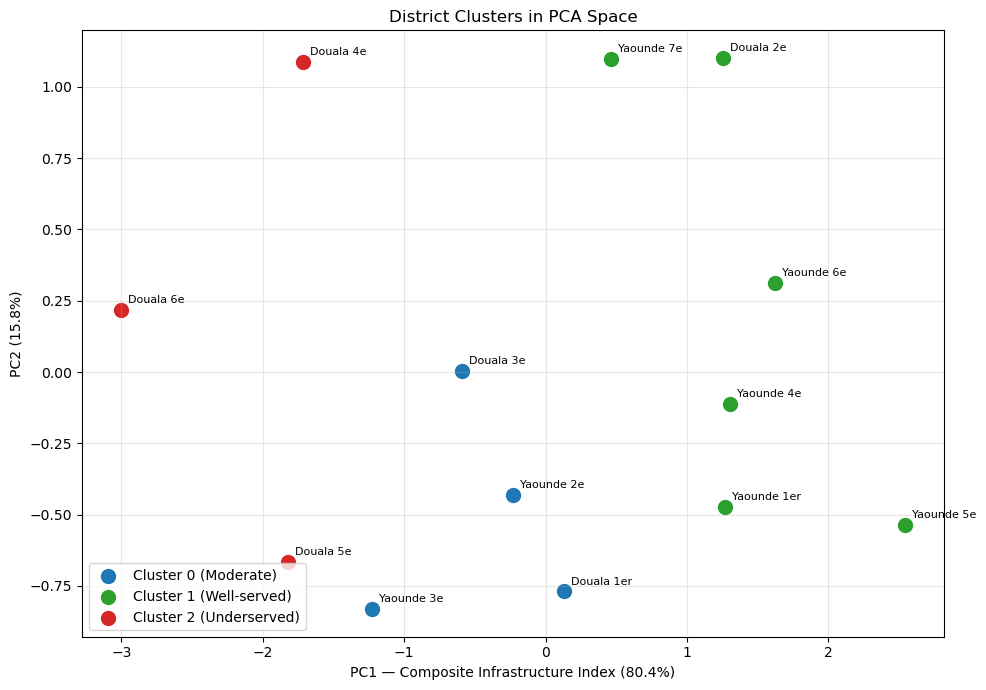

In [8]:
# PCA 공간에서 군집 시각화
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#1f77b4', '#2ca02c', '#d62728']
cluster_labels = ['Cluster 0 (Moderate)', 'Cluster 1 (Well-served)', 'Cluster 2 (Underserved)']

for c in sorted(df['cluster'].unique()):
    sub = df[df['cluster'] == c]
    ax.scatter(sub['infra_index'], sub['PC2'], c=colors[c], label=cluster_labels[c], s=100)

for i, row in df.iterrows():
    ax.annotate(row['district_name'], (row['infra_index'], row['PC2']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('PC1 — Composite Infrastructure Index (80.4%)')
ax.set_ylabel('PC2 (15.8%)')
ax.set_title('District Clusters in PCA Space')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/pca_clusters.png', dpi=150)
plt.show()

In [9]:
# 최종 분석 결과 저장
final = df[['district_name', 'city', 'mean_radiance', 'road_density_km_per_sqkm',
            'water_density_km_per_sqkm', 'infra_index', 'cluster']].copy()

# 군집 라벨 붙이기
cluster_names = {0: 'Moderate', 1: 'Well-served', 2: 'Underserved'}
final['cluster_label'] = final['cluster'].map(cluster_names)

final.to_csv('../data/processed/final_analysis_results.csv', index=False)
print("저장 완료!")
print(final.to_string(index=False))

저장 완료!
district_name    city  mean_radiance  road_density_km_per_sqkm  water_density_km_per_sqkm  infra_index  cluster cluster_label
   Douala 1er  Douala      13.997540                  8.266550                   0.858671     0.132775        0      Moderate
    Douala 2e  Douala      10.254959                 12.203973                   1.490258     1.252603        1   Well-served
    Douala 3e  Douala       6.136908                  9.896716                   0.839167    -0.590097        0      Moderate
    Douala 4e  Douala       2.287667                  2.493050                   0.997815    -1.713023        2   Underserved
    Douala 5e  Douala       4.262470                  6.991505                   0.449427    -1.820200        2   Underserved
    Douala 6e  Douala       0.367691                  0.107476                   0.535103    -3.002721        2   Underserved
  Yaounde 1er Yaounde      14.165398                 14.338806                   1.066296     1.270814        1